# Credit Card Portfolio Monitor
### John C. Hutcheson — Credit & Portfolio Analytics

**What this is:** a portfolio-level credit risk analysis of a consumer credit card book comprised of delinquency profile,
roll-rate transitions, vintage performance, expected loss, and an industry benchmark against Federal Reserve data. one-page leadership summary .

**Why it exists:** credit risk work isn't just computing numbers; it's turning portfolio data into decisions
leadership can act on. Every section below pairs the analysis with a plain-English read of *what it means for the book*.

*Data note: this notebook runs on a realistic synthetic portfolio (generated below, seeded for reproducibility)
so it executes anywhere out of the box. Section 1 notes where to swap in real data
(e.g., the UCI "Default of Credit Card Clients" dataset).*

## 1. Setup & Portfolio Data

**What this block does:** loads our tools (pandas = spreadsheets in code, matplotlib = charts) and builds a
synthetic portfolio of 20,000 card accounts with realistic relationships (lower FICO tends to mean higher
utilization and worse delinquency, newer accounts season over time, etc.)


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)   # seeded → same portfolio every run
N = 20_000                        # number of card accounts

# --- borrower quality: FICO scores, skewed prime (this is a mass-affluent style book) ---
fico = np.clip(rng.normal(735, 55, N).astype(int), 520, 850)

# --- credit limits scale loosely with FICO ---
limit = np.round(np.clip(rng.normal((fico - 400) * 40, 3000, N), 1000, 40000), -2)

# --- utilization: lower-FICO borrowers run hotter balances ---
util_mean = np.clip(1.05 - (fico - 520) / 400, 0.05, 0.95)
utilization = np.clip(rng.beta(2, 5, N) * util_mean * 2.2, 0, 1)
balance = np.round(limit * utilization, 2)

# --- months on book (vintage): 1 to 60 months ---
months_on_book = rng.integers(1, 61, N)

# --- delinquency status (days past due bucket) driven by FICO + utilization + a little luck ---
risk_score = (760 - fico) / 240 * 0.6 + utilization * 0.4 + rng.normal(0, 0.08, N)
dpd_bucket = np.select(
    [risk_score > 0.78, risk_score > 0.70, risk_score > 0.62, risk_score > 0.52],
    ["90+", "60-89", "30-59", "1-29"], default="Current")

port = pd.DataFrame({
    "account_id": np.arange(1, N + 1),
    "fico": fico,
    "credit_limit": limit,
    "balance": balance,
    "utilization": utilization.round(3),
    "months_on_book": months_on_book,
    "dpd_bucket": pd.Categorical(dpd_bucket,
        categories=["Current", "1-29", "30-59", "60-89", "90+"], ordered=True),
})

print(f"Portfolio: {len(port):,} accounts | ${port.balance.sum()/1e6:,.1f}M in receivables")
port.head()

Portfolio: 20,000 accounts | $82.7M in receivables


,account_id,fico,credit_limit,balance,utilization,months_on_book,dpd_bucket
0,1,751,9100.0,1154.77,0.127,1,Current
1,2,677,13800.0,477.83,0.035,39,Current
2,3,776,14900.0,4756.75,0.319,53,Current
3,4,786,13600.0,3585.28,0.264,2,Current
4,5,627,8300.0,5058.16,0.609,47,30-59


> **Analyst Summary**

---


The book holds 20,000 accounts and $82.7M in receivables, with an average FICO of 734 and 91% of accounts scoring prime or better. Therefore, we can assume the subject of analysis is a prime-skewed consumer card portfolio. So, risk sits at the margin and not the core of the borrowers, for delinquent accounts average 646 FICO, and roughly 4-in-10 sub-660 borrowers are past due, while the prime abse remains overwhelmingly current. Therefore, evidence supports the fact that credit utilization runs inverse o credit quality: the weakest borrowers run the hottest lines. Low FICO borrowers require intensive monitoring to mitigate defaukt risk.

## 2. Portfolio Overview — Who Are We Lending To?

**What this block does:** draws the FICO distribution and utilization pattern. In credit risk, these two charts
are the first thing you look at: quality of the borrower, and how hot they're running their lines.

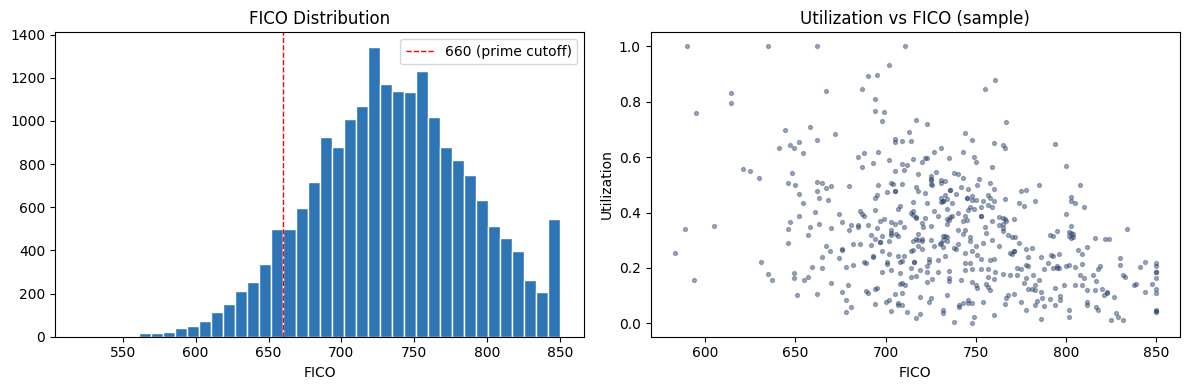

Prime+ share of accounts: 91.2%
Average utilization: 32.3%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(port.fico, bins=40, color="#2E75B6", edgecolor="white")
axes[0].axvline(660, color="red", ls="--", lw=1, label="660 (prime cutoff)")
axes[0].set_title("FICO Distribution"); axes[0].set_xlabel("FICO"); axes[0].legend()

axes[1].scatter(port.fico[::40], port.utilization[::40], s=8, alpha=0.4, color="#1F3864")
axes[1].set_title("Utilization vs FICO (sample)"); axes[1].set_xlabel("FICO"); axes[1].set_ylabel("Utilization")

plt.tight_layout(); plt.show()

prime_share = (port.fico >= 660).mean()
print(f"Prime+ share of accounts: {prime_share:.1%}")
print(f"Average utilization: {port.utilization.mean():.1%}")

> **Analyst Summary**

---


The prime and better borrowers hold 91.2% of accounts, and utilization averages 32.3% across the book. The exposure worth watching is the overlap: low-FICO borrowers run closest to their limits, and rising utilization among weaker credits is one of the earliest observable signals of stress because borrowers draw down available lines before they miss payments. That combination raises expected loss and, in turn, raises the reserve required against it, which makes low-FICO, high utilization accounts the natural priority for line management and monitoring.

## 3. Delinquency Profile — Where Does the Book Stand Today?

**What this block does:** counts accounts and dollars in each days-past-due bucket.

In [11]:
delinq = port.groupby("dpd_bucket", observed=True).agg(
    accounts=("account_id", "count"),
    balance=("balance", "sum"))
delinq["pct_accounts"] = (delinq.accounts / delinq.accounts.sum() * 100).round(2)
delinq["pct_balance"]  = (delinq.balance  / delinq.balance.sum()  * 100).round(2)

# The headline number: 30+ DPD rate on BALANCES (the industry convention)
rate_30plus = delinq.loc[["30-59", "60-89", "90+"], "balance"].sum() / delinq.balance.sum()
print(f"30+ DPD delinquency rate (balance-weighted): {rate_30plus:.2%}")
delinq

delinq_mask = port["dpd_bucket"].isin(["30-59", "60-89", "90+"])

acct_rate = delinq_mask.mean()
avg_bal_delinq = port.loc[delinq_mask, "balance"].mean()
avg_bal_rest = port.loc[~delinq_mask, "balance"].mean()

print(f"Account-weighted 30+ DPD: {acct_rate:.2%}")
print(f"Avg balance — delinquent: ${avg_bal_delinq:,.0f} | rest of book: ${avg_bal_rest:,.0f}")

30+ DPD delinquency rate (balance-weighted): 3.70%
Account-weighted 30+ DPD: 2.14%
Avg balance — delinquent: $7,163 | rest of book: $4,067


> **Analyst Summary**

---

The book's 30+ DPD rate is 3.70% on a balance-weighted basis against 2.14% by account-weighted measure. Delinquent accounts carry an average balance of \$7613 compared to an average value of \$4067 for the rest of the book. Larger balances default more often, so account-based reporting understates the dollars actually at risk. Portfolio reporting should lead with balance-weighted delinquency for that reason.




## 4. Roll-Rate Matrix — How Do Accounts Move Between Buckets?

**What this block does:** simulates one month of bucket transitions and builds the roll-rate matrix (the
probability an account in bucket X lands in bucket Y next month.)

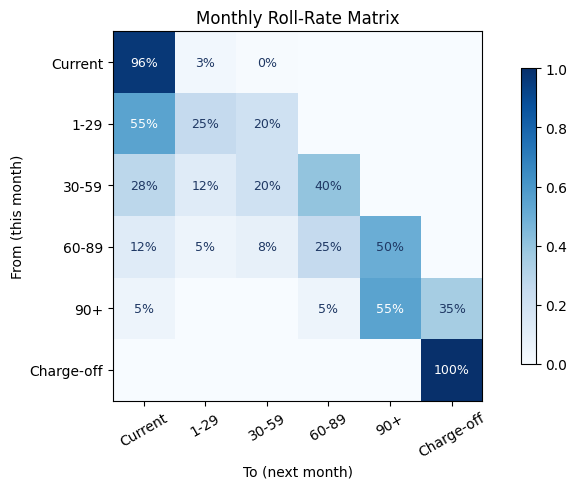

Read one row: 'Of accounts 60-89 DPD this month, 50% roll to 90+, 25% stay, 12% cure to current.'


In [12]:
buckets = ["Current", "1-29", "30-59", "60-89", "90+", "Charge-off"]

# Realistic monthly transition probabilities (rows = from, cols = to)
T = pd.DataFrame([
    # Current  1-29   30-59  60-89  90+    CO
    [0.965,  0.030, 0.005, 0.000, 0.000, 0.000],   # from Current
    [0.55,   0.25,  0.20,  0.000, 0.000, 0.000],   # from 1-29   (55% cure!)
    [0.28,   0.12,  0.20,  0.40,  0.000, 0.000],   # from 30-59
    [0.12,   0.05,  0.08,  0.25,  0.50,  0.000],   # from 60-89
    [0.05,   0.00,  0.00,  0.05,  0.55,  0.35],    # from 90+   (35% → charge-off)
    [0.00,   0.00,  0.00,  0.00,  0.00,  1.00],    # Charge-off is absorbing
], index=buckets, columns=buckets)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(T.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(6), buckets, rotation=30); ax.set_yticks(range(6), buckets)
ax.set_xlabel("To (next month)"); ax.set_ylabel("From (this month)")
ax.set_title("Monthly Roll-Rate Matrix")
for i in range(6):
    for j in range(6):
        if T.iloc[i, j] > 0:
            ax.text(j, i, f"{T.iloc[i,j]:.0%}", ha="center", va="center",
                    color="white" if T.iloc[i, j] > 0.5 else "#1F3864", fontsize=9)
plt.colorbar(im, shrink=0.8); plt.tight_layout(); plt.show()

print("Read one row: 'Of accounts 60-89 DPD this month, 50% roll to 90+, 25% stay, 12% cure to current.'")

> **Analyst Summary**

---
Early-stage delinquency largely self-corrects: 55% of accounts 1-29 days past due cure to current within a month, so collections effort is best concentrated where cure probability drops off rather than on first-miss accounts. Late-stage behavior is the opposite: 35% of 90+ balances roll to charge-off and only 5% return to current, meaning losses are effectivley determined well before write-off. The 30-59 to 60-89 transition, currently 40%, is the metric to watch: a sustained move towards the high 40s would signal deterioration roughly two quarrters before it appears in charge-offs, and would warrant tightening line increases and stepping up collections contact ahead of the loss emerging.


## 5. Vintage View — Is Underwriting Drifting?

**What this block does:** plots delinquency by account age (months on book). Card losses follow a seasoning
curve: new accounts look clean, delinquency peaks around months 18–30, then seasoned survivors settle down.


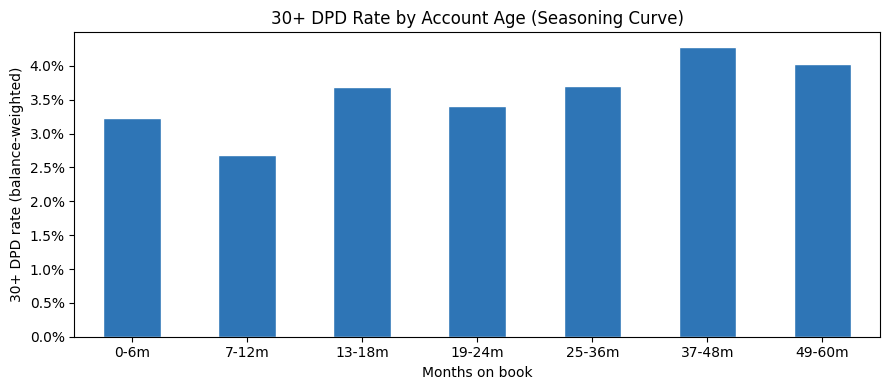

In [13]:
port["vintage_bucket"] = pd.cut(port.months_on_book, bins=[0, 6, 12, 18, 24, 36, 48, 60],
    labels=["0-6m", "7-12m", "13-18m", "19-24m", "25-36m", "37-48m", "49-60m"])

vint = port.groupby("vintage_bucket", observed=True).apply(
    lambda g: g.loc[g.dpd_bucket.isin(["30-59", "60-89", "90+"]), "balance"].sum() / g.balance.sum(),
    include_groups=False)

fig, ax = plt.subplots(figsize=(9, 4))
vint.plot(kind="bar", color="#2E75B6", ax=ax, edgecolor="white")
ax.set_title("30+ DPD Rate by Account Age (Seasoning Curve)")
ax.set_ylabel("30+ DPD rate (balance-weighted)"); ax.set_xlabel("Months on book")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

> Analyst Summary

---

This portfolio shows no meaningful relationship between account age and delinquency. 30+ rates range from 2.7% to 4.3% across vintage buckets with no directional pattern, and the correlation between months on book and delinquency status is effectively zero. The practical implication for a growing book is as follows: rapid origination growth mechanically improves observed delinquency rates while young accounts have uet to season, even as CECL requires lifetime reserves on thos same accounts from day one. Clean headline metrics and rising provision expense can therefore appear together.

## 6. Expected Loss — What Should We Reserve?

**What this block does:** applies the core credit risk equation, **Expected Loss = PD × LGD × EAD**, by FICO
segment. PDs rise as FICO falls; LGD on unsecured cards is high (~85% — little to recover); EAD is the balance
(plus a haircut of the undrawn line, since stressed borrowers draw down before defaulting).

In [14]:
seg = pd.cut(port.fico, bins=[0, 620, 660, 720, 780, 850],
             labels=["<620", "620-659", "660-719", "720-779", "780+"])

# Annual PD assumptions by segment (illustrative, directionally realistic for cards)
pd_map  = {"<620": 0.16, "620-659": 0.09, "660-719": 0.045, "720-779": 0.018, "780+": 0.006}
LGD = 0.85                       # unsecured — recoveries are thin
CCF = 0.40                       # credit conversion factor on undrawn line

el = port.assign(segment=seg).groupby("segment", observed=True).apply(
    lambda g: pd.Series({
        "balance":  g.balance.sum(),
        "EAD":      (g.balance + CCF * (g.credit_limit - g.balance)).sum(),
        "PD":       pd_map[g.name],
    }), include_groups=False)
el["expected_loss"] = el.PD * LGD * el.EAD
el["EL_rate_on_balance"] = el.expected_loss / el.balance

total_el = el.expected_loss.sum()
print(f"Total 12-month expected loss: ${total_el/1e6:.1f}M "
      f"({total_el / port.balance.sum():.2%} of receivables)")
el.round(3)

Total 12-month expected loss: $3.9M (4.76% of receivables)


,balance,EAD,PD,expected_loss,EL_rate_on_balance
segment,,,,,
<620,1656374.83,2.225225e+06,0.160,302630.586,0.183
620-659,6253222.76,9.311374e+06,0.090,712320.085,0.114
660-719,27928160.15,4.573574e+07,0.045,1749391.905,0.063
720-779,33338016.63,6.466505e+07,0.018,989375.265,0.030
780+,13489817.81,3.476673e+07,0.006,177310.326,0.013


> Analyst Summary


---

Twelve-month expected loss totals to \$3.9M, or 4.76% of receivables. The 660-719 segment drives it: 33.8% of balances but 44.5% of expected loss, so not the riskiest segment (sub-620 borrowers default at roughly 16% versus 4.5% here), but the largest, which is where dollar losses concentrate. Exposure at default runs \$156.7M against \$82.7M in current balances, because stressed borrowers draw on available credit before they default; the model assumes 40% of the book's \$185.1M in undrawn lines converts to balance on the way to default. That is why line increases carry credit risk even when balances look modest today. This calculation frames the reserves, but requires supportable forecasts of unemployment, rates, and consumer stress reflected in the CECL model.

## 7. Industry Benchmark — Federal Reserve Data

**What this block does:** compares our book against industry delinquency and charge-off rates for credit cards
at all commercial banks (Federal Reserve, via FRED).

Using stored Q1 2026 FRED values (add a fredapi key for live data).


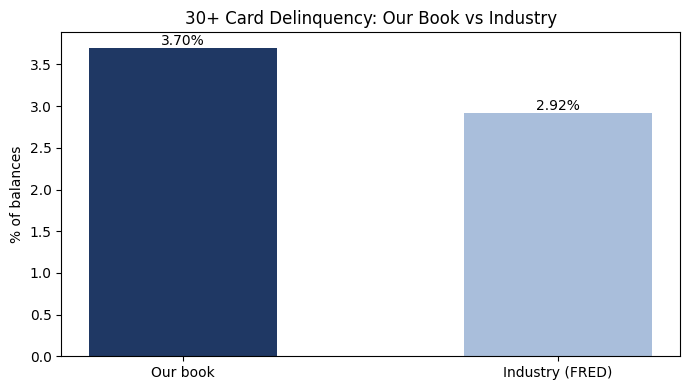

Our book: 3.70%  |  Industry: 2.92%  |  Industry charge-offs: 3.84%


In [15]:
industry = {"card_delinquency": 2.92, "card_charge_off": 3.84}   # Q1 2026, FRED (fallback)

try:
    from fredapi import Fred                      # pip install fredapi
    fred = Fred(api_key="YOUR_KEY_HERE")          # ← paste your free key
    industry["card_delinquency"] = float(fred.get_series("DRCCLACBS").dropna().iloc[-1])
    industry["card_charge_off"]  = float(fred.get_series("CORCCACBS").dropna().iloc[-1])
    print("Pulled live FRED data.")
except Exception:
    print("Using stored Q1 2026 FRED values (add a fredapi key for live data).")

our_delinq = rate_30plus * 100
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["Our book", "Industry (FRED)"], [our_delinq, industry["card_delinquency"]],
              color=["#1F3864", "#A9BEDB"], width=0.5)
ax.bar_label(bars, fmt="%.2f%%")
ax.set_title("30+ Card Delinquency: Our Book vs Industry")
ax.set_ylabel("% of balances"); plt.tight_layout(); plt.show()

print(f"Our book: {our_delinq:.2f}%  |  Industry: {industry['card_delinquency']:.2f}%  "
      f"|  Industry charge-offs: {industry['card_charge_off']:.2f}%")

> Analyst Summary

---
The book's 30+ DPD rate of 3.70% sits 78 basis points above the industry benchmark of 2.92% for credit card loans at all commercial banks (FRED, Q1 2026). That comparison does not reconcile with the portfolio's composition, for a book that is 91% prime with an average FICO of 734 should run below an industry average that includes substantial subprime exposure.


## 8. Leadership Summary


---

### Card Portfolio Credit Review — [August, 2026]

**Portfolio:** [20,000 accounts, \$82.7M receivables, average FICO 734, 91% prime or better share]

**Key findings:**
1. Credit risk is concentrated at the margin, not the core: delinquent accounts average a 646 FICO and roughly 4-in-10 sub-660 borrowers are past due, while the prime base remains overwhelmingly current.
2. Delinquency runs 3.70% balance-weighted versus 2.14% by account-weighted measures, because delinquent accounts carry \$7,613 in average balance against \$4,067 for the rest of the book. Account-based reporting understates the dollars at risk by nearly half.
3. Expected loss totals \$3.9M, or 4.76% of receivables, and concentrates in the 660-719 segment, which holds 33.8% of balances but drives 44.5% of loss and makes it the largest, not the riskeist, segment.
4. exposure at default is \$156.7M against \$82.7M of current balances, since stressed borrowers draw down available credit before defaulting. Undrwan lines are exposure, and line increases are credit decisions.
5. The 30-59 to 60-89 roll-rate, currently 40%, is the leading indicator to watch: a sustained move toward the high 40s would signal deterioration roughly two quarters before it reaches charge-offs.



---
**Requires Reconciliation**

The book's 3.70% delinquency sits 78 basis points above the 2.92% industry benchmark, which is inconsistent with a 91% prime portfolio and should be investigated further through definitional comparability first, then the delinquency flag's population before the figure informs any reserve decision.

**Recommendation**

Maintain current reserve levels pending that reconciliation, prioritize line management for low-FICO high utilization accounts, and monitor the 30-59 to 60-89 transition monthly as the portfolio's earliest warning signal.

---

*Prepared by John C. Hutcheson • Methodology: roll-rate and vintage analysis, PD×LGD×EAD expected loss,
FRED industry benchmarking • Data: synthetic demonstration portfolio*